In [1]:
!pip install -q kaggle

from google.colab import files
import os

uploaded = files.upload()

if 'kaggle.json' in uploaded:
    if not os.path.exists('/root/.kaggle'):
        os.makedirs('/root/.kaggle')
    !mv kaggle.json /root/.kaggle/
    !chmod 600 /root/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [2]:
import pandas as pd
import numpy as np

!kaggle datasets download -d uciml/pima-indians-diabetes-database -q
!unzip -o pima-indians-diabetes-database.zip

df = pd.read_csv('diabetes.csv')

cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)
df.fillna(df.mean(), inplace=True)

display(df.head())

Dataset URL: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
License(s): CC0-1.0
Archive:  pima-indians-diabetes-database.zip
  inflating: diabetes.csv            


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.00000,155.548223,33.6,0.627,50,1
1,1,85.0,66.0,29.00000,155.548223,26.6,0.351,31,0
2,8,183.0,64.0,29.15342,155.548223,23.3,0.672,32,1
3,1,89.0,66.0,23.00000,94.000000,28.1,0.167,21,0
4,0,137.0,40.0,35.00000,168.000000,43.1,2.288,33,1


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('Outcome', axis=1)
y = df['Outcome']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

log_reg_model = LogisticRegression(random_state=42)
log_reg_model.fit(X_train, y_train)

y_pred_log_reg = log_reg_model.predict(X_test)

log_reg_accuracy = accuracy_score(y_test, y_pred_log_reg)
log_reg_precision = precision_score(y_test, y_pred_log_reg)
log_reg_recall = recall_score(y_test, y_pred_log_reg)
log_reg_cm = confusion_matrix(y_test, y_pred_log_reg)

results = {}
results['Logistic Regression'] = {
    'Accuracy': log_reg_accuracy,
    'Precision': log_reg_precision,
    'Recall': log_reg_recall,
    'Confusion Matrix': log_reg_cm
}

summary_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall'],
    'Score': [log_reg_accuracy, log_reg_precision, log_reg_recall]
})
display(summary_df)

,Metric,Score
0,Accuracy,0.694805
1,Precision,0.577778
2,Recall,0.481481


In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

ann_model = Sequential([
    Dense(12, input_shape=(8,), activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

ann_model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=0)

y_pred_proba_ann = ann_model.predict(X_test)
y_pred_ann = (y_pred_proba_ann > 0.5).astype("int32")

ann_accuracy = accuracy_score(y_test, y_pred_ann)
ann_precision = precision_score(y_test, y_pred_ann)
ann_recall = recall_score(y_test, y_pred_ann)
ann_cm = confusion_matrix(y_test, y_pred_ann)

results['ANN'] = {
    'Accuracy': ann_accuracy,
    'Precision': ann_precision,
    'Recall': ann_recall,
    'Confusion Matrix': ann_cm
}

summary_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall'],
    'Score': [ann_accuracy, ann_precision, ann_recall]
})
display(summary_df)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


,Metric,Score
0,Accuracy,0.714286
1,Precision,0.589286
2,Recall,0.611111


In [6]:
from sklearn.cluster import KMeans
from scipy.stats import mode

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
train_clusters = kmeans.fit_predict(X_train)

cluster_map = {}
for i in range(2):
    mask = (train_clusters == i)
    cluster_map[i] = mode(y_train[mask])[0]

test_clusters = kmeans.predict(X_test)

y_pred_kmeans = np.vectorize(cluster_map.get)(test_clusters)

kmeans_accuracy = accuracy_score(y_test, y_pred_kmeans)
kmeans_precision = precision_score(y_test, y_pred_kmeans)
kmeans_recall = recall_score(y_test, y_pred_kmeans)
kmeans_cm = confusion_matrix(y_test, y_pred_kmeans)

results['K-Means'] = {
    'Accuracy': kmeans_accuracy,
    'Precision': kmeans_precision,
    'Recall': kmeans_recall,
    'Confusion Matrix': kmeans_cm
}

summary_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall'],
    'Score': [kmeans_accuracy, kmeans_precision, kmeans_recall]
})
display(summary_df)

,Metric,Score
0,Accuracy,0.655844
1,Precision,0.507042
2,Recall,0.666667


,Accuracy,Precision,Recall
Logistic Regression,0.694805,0.577778,0.481481
ANN,0.714286,0.589286,0.611111
K-Means,0.655844,0.507042,0.666667


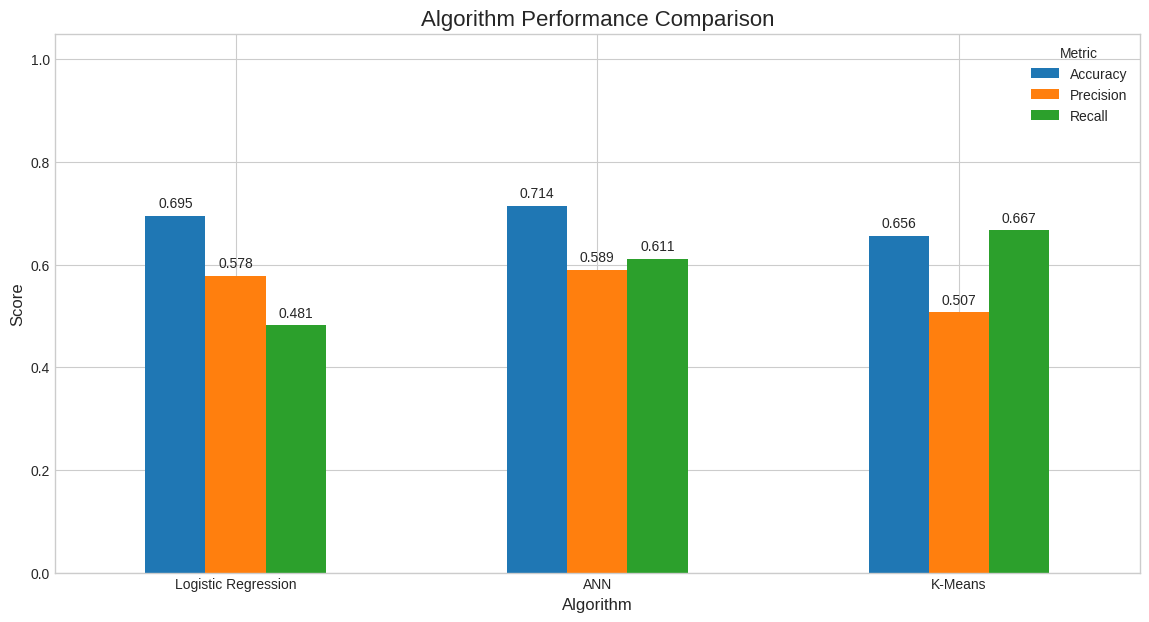

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

comparison_df = pd.DataFrame(results).T.drop(columns='Confusion Matrix')

display(comparison_df.round(3))

plt.style.use('seaborn-v0_8-whitegrid')
fig = comparison_df.plot(kind='bar', figsize=(14, 7), rot=0)
plt.title('Algorithm Performance Comparison', fontsize=16)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Algorithm', fontsize=12)
plt.ylim(0, 1.05)
plt.legend(title='Metric')

for p in fig.patches:
    fig.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.show()

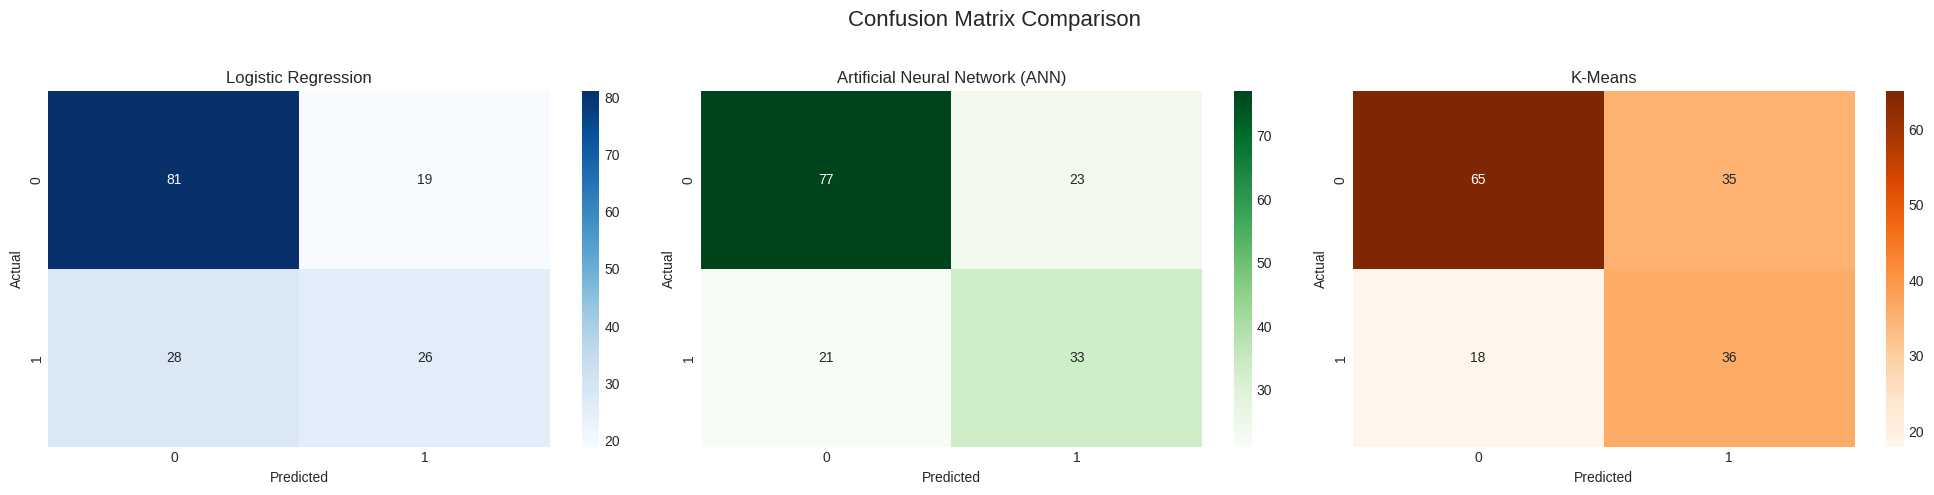

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Logistic Regression
sns.heatmap(results['Logistic Regression']['Confusion Matrix'], annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ANN
sns.heatmap(results['ANN']['Confusion Matrix'], annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Artificial Neural Network (ANN)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')


# K-Means
sns.heatmap(results['K-Means']['Confusion Matrix'], annot=True, fmt='d', cmap='Oranges', ax=axes[2])
axes[2].set_title('K-Means')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.suptitle('Confusion Matrix Comparison', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()